# MLIA PS1 Solution
### By Sravanth Chowdary Potluri und5uv

#### *Programming Assisted With the help of ChatGPT and Github Copilot

### Question 2

In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

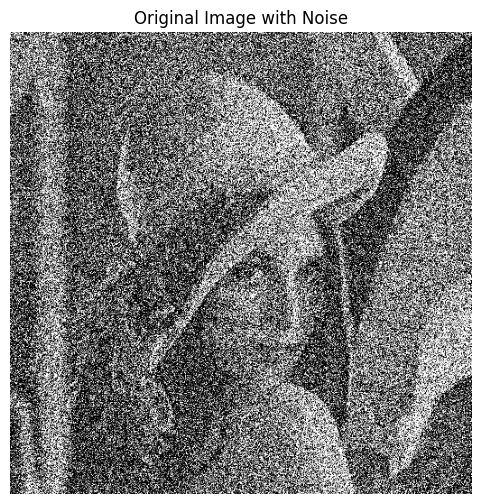

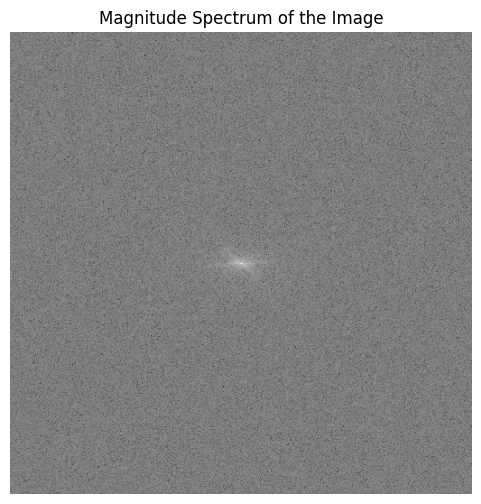

In [2]:
# Load the image (make sure 'lenaNoise.PNG' is in your working directory)
image = Image.open('PS1/lenaNoise.png')
image_np = np.array(image)

# Displaying the original image
plt.figure(figsize=(6, 6))
plt.imshow(image_np, cmap='gray')
plt.title('Original Image with Noise')
plt.axis('off')
plt.show()

# Computing Fourier Transform
f_transform = np.fft.fft2(image_np)

# Shifting the zero-frequency component to the center
f_shifted = np.fft.fftshift(f_transform)

# Displaying the fourier magnitude spectrum image
magnitude_spectrum = 20 * np.log(np.abs(f_shifted) + 1)  # Add 1 to avoid log(0)

plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum of the Image')
plt.axis('off')
plt.show()

In [3]:
# Function to create a mask that give a filter a square of low frequencies
def create_low_pass_mask(shape, size):
    rows, cols = shape
    mask = np.zeros((rows, cols), dtype=np.uint8)
    crow, ccol = rows // 2 , cols // 2  # Center
    half_size = size // 2

    # Ensure the size does not exceed the image dimensions
    half_size = min(half_size, crow, ccol)

    # Set ones in the mask in the low-frequency region
    mask[crow - half_size : crow + half_size, ccol - half_size : ccol + half_size] = 1

    return mask

# Sizes of low-frequency regions to keep
sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512]  # Ensure the size does not exceed image dimensions

# Prepare a dictionary to store the filtered transforms
filtered_transforms = {}

for size in sizes:
    mask = create_low_pass_mask(image_np.shape, size)
    f_filtered = f_shifted * mask  # Element-wise multiplication
    filtered_transforms[size] = f_filtered

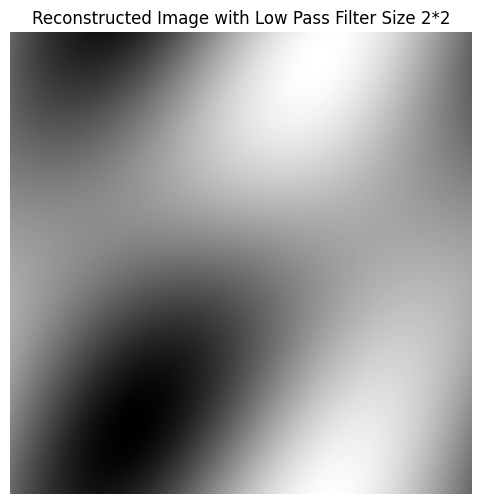

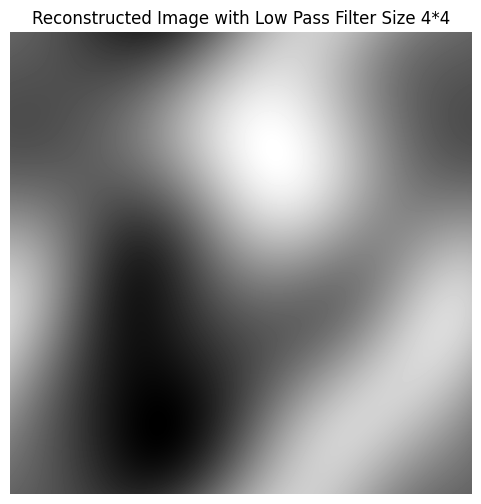

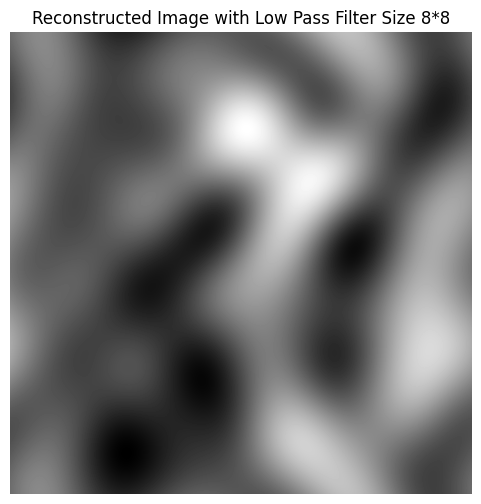

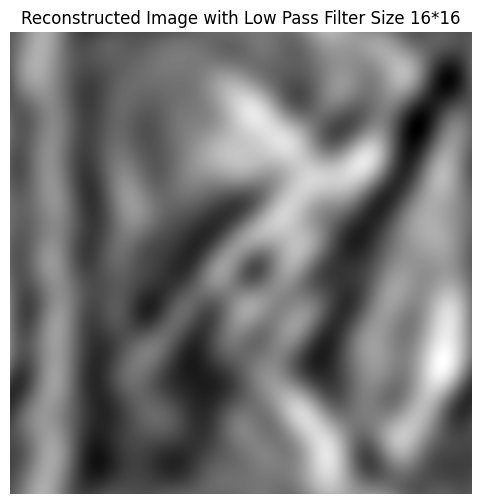

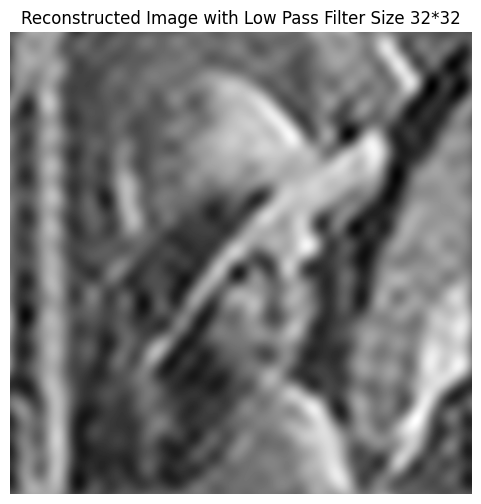

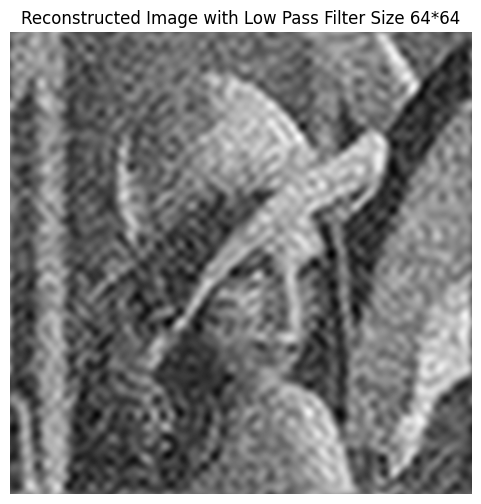

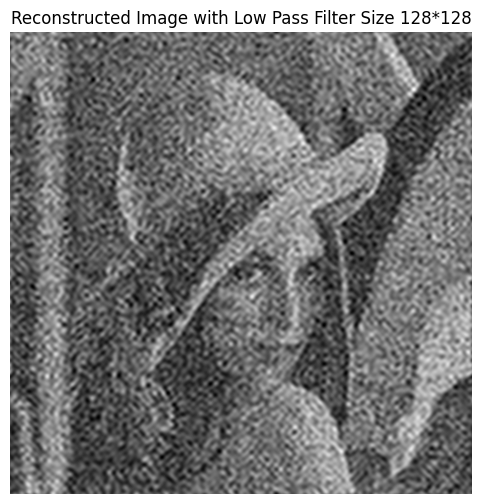

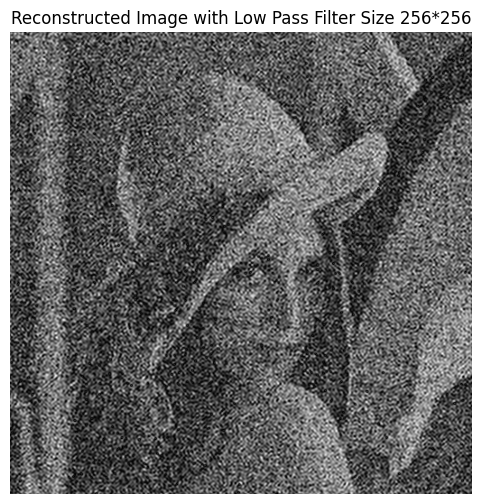

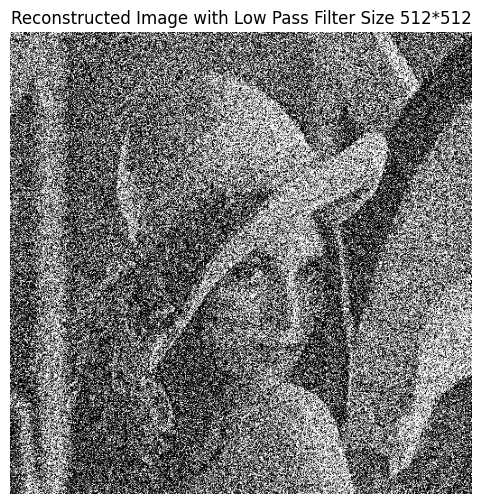

In [4]:
# Reconstruct the images using the inverse Fourier Transform
for size in sizes:
    # Getting the filtered transform
    f_filtered = filtered_transforms[size]

    # Shift back (inverse shift)
    f_ishifted = np.fft.ifftshift(f_filtered)

    # Computing the inverse Fourier Transform
    img_reconstructed = np.fft.ifft2(f_ishifted)

    # (magnitude)
    img_reconstructed = np.abs(img_reconstructed)

    # Displaying the reconstructed image
    plt.figure(figsize=(6, 6))
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f'Reconstructed Image with Low Pass Filter Size {size}*{size}')
    plt.axis('off')
    plt.show()

### Question 3

In [5]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.ndimage

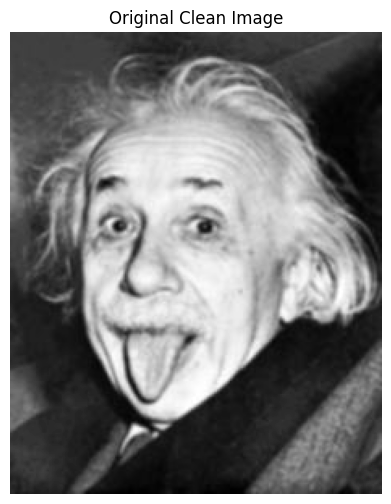

In [6]:
# Load the image (make sure 'Einstein.jpeg' is in your working directory)
image = Image.open('PS1/Einstein.jpeg').convert('L')  # Convert to grayscale
image_np = np.array(image, dtype=np.float64) / 255.0  # Normalize to [0, 1]

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image_np, cmap='gray')
plt.title('Original Clean Image')
plt.axis('off')
plt.show()

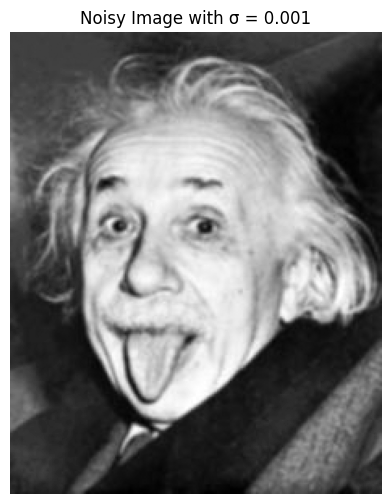

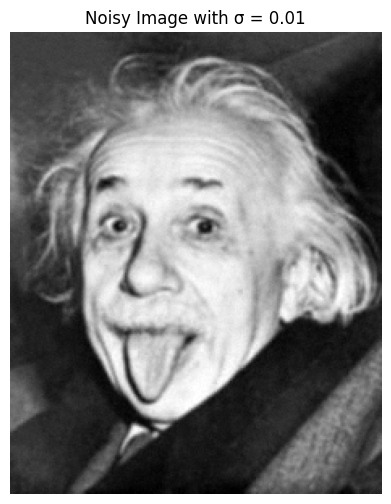

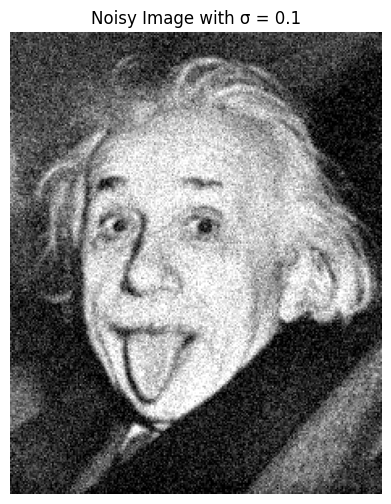

In [7]:
# Function to add Gaussian noise to the image
def add_gaussian_noise(image, sigma):
    noisy_image = image + np.random.normal(0, sigma, image.shape)
    noisy_image = np.clip(noisy_image, 0, 1)  # Ensure values are within [0, 1]
    return noisy_image

# Noise variances
sigmas = [0.001, 0.01, 0.1]

# Dictionary to store noisy images
noisy_images = {}

for sigma in sigmas:
    noisy_img = add_gaussian_noise(image_np, sigma)
    noisy_images[sigma] = noisy_img

    # Display the noisy image
    plt.figure(figsize=(6, 6))
    plt.imshow(noisy_img, cmap='gray')
    plt.title(f'Noisy Image with σ = {sigma}')
    plt.axis('off')
    plt.show()

In [8]:
# Compute gradients using forward differences
def compute_gradient(u):
    Dux = np.zeros_like(u)
    Duy = np.zeros_like(u)

    Dux[:, :-1] = u[:, 1:] - u[:, :-1]  # Gradient in x-direction
    Duy[:-1, :] = u[1:, :] - u[:-1, :]  # Gradient in y-direction

    return Dux, Duy

# Compute divergence using backward differences
def compute_divergence(p, q):
    div = np.zeros_like(p)

    div[:, :-1] += p[:, :-1]
    div[:, 1:] -= p[:, :-1]
    div[:-1, :] += q[:-1, :]
    div[1:, :] -= q[:-1, :]

    return div

In [9]:
# Total Variation Denoising using Gradient Descent
def tv_denoise(f, lambda_param=0.02, alpha=0.2, iterations=200):
    u = f.copy()  # Initialize u^0 = f
    E_list = []   # List to store energy values

    epsilon = 1e-8  # Small constant to avoid division by zero

    for k in range(iterations):
        # Compute gradients
        Dux, Duy = compute_gradient(u)

        # Compute gradient magnitude
        grad_magnitude = np.sqrt(Dux**2 + Duy**2 + epsilon)

        # Normalize gradients
        Dux_norm = Dux / grad_magnitude
        Duy_norm = Duy / grad_magnitude

        # Compute divergence
        div_pq = compute_divergence(Dux_norm, Duy_norm)

        # Compute the gradient of E(u)
        grad_E = 2 * lambda_param * (u - f) - div_pq

        # Update u
        u = u - alpha * grad_E

        # Compute the energy E(u)
        E = lambda_param * np.sum((u - f)**2) + np.sum(grad_magnitude)
        E_list.append(E)

        # Optional: Print progress every 20 iterations
        if (k + 1) % 20 == 0:
            print(f'Iteration {k+1}/{iterations}, Energy: {E:.4f}')

    return u, E_list


Denoising image with σ = 0.001
Iteration 20/100, Energy: 1881.1739
Iteration 40/100, Energy: 1799.5536
Iteration 60/100, Energy: 1773.5612
Iteration 80/100, Energy: 1764.0060
Iteration 100/100, Energy: 1760.0721


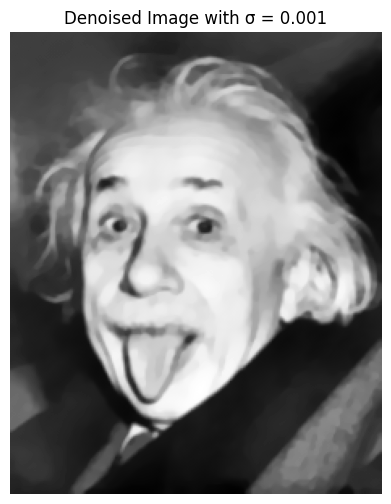


Denoising image with σ = 0.01
Iteration 20/100, Energy: 1942.3487
Iteration 40/100, Energy: 1852.3442
Iteration 60/100, Energy: 1825.5902
Iteration 80/100, Energy: 1815.8004
Iteration 100/100, Energy: 1811.3421


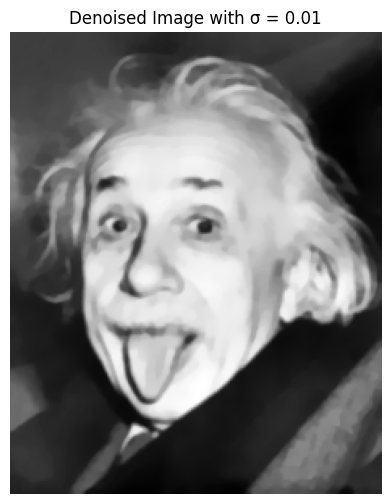


Denoising image with σ = 0.1
Iteration 20/100, Energy: 4632.9234
Iteration 40/100, Energy: 4640.2393
Iteration 60/100, Energy: 4643.2320
Iteration 80/100, Energy: 4648.8319
Iteration 100/100, Energy: 4645.8206


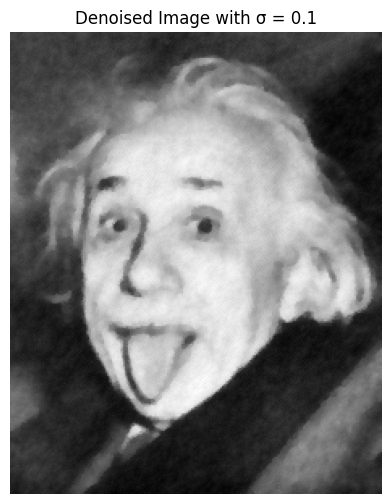

In [10]:
# Dictionary to store denoised images and energy lists
denoised_images = {}
energy_lists = {}

# Parameters for TV denoising
sigma_params = {}
sigma_params[0.001] = [10, 0.001, 100]
sigma_params[0.01] = [10, 0.001, 100]
sigma_params[0.1] = [4, 0.01, 100]

for sigma in sigmas:
    print(f'\nDenoising image with σ = {sigma}')
    f_noisy = noisy_images[sigma]
    
    u_denoised, E_list = tv_denoise(f_noisy, lambda_param=sigma_params[sigma][0], alpha=sigma_params[sigma][1], iterations=sigma_params[sigma][2])
    
    denoised_images[sigma] = u_denoised
    energy_lists[sigma] = E_list
    
    # Display the denoised image
    plt.figure(figsize=(6, 6))
    plt.imshow(u_denoised, cmap='gray')
    plt.title(f'Denoised Image with σ = {sigma}')
    plt.axis('off')
    plt.show()

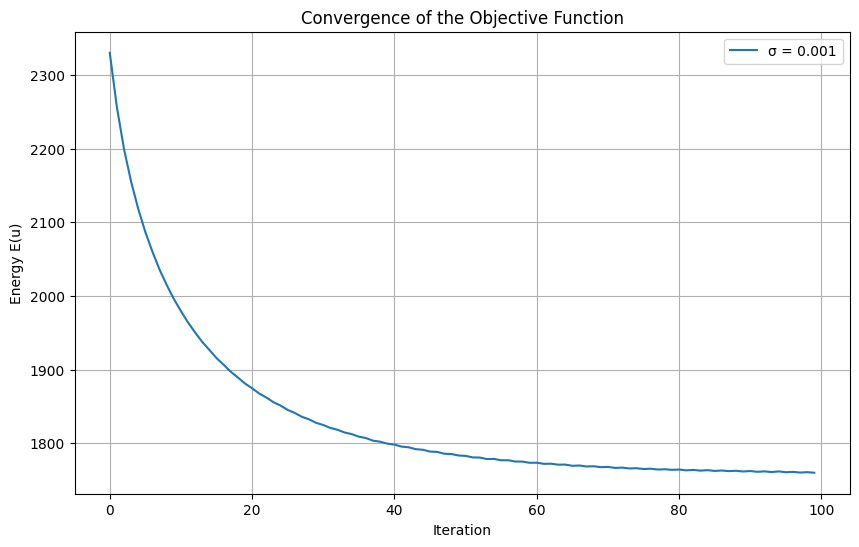

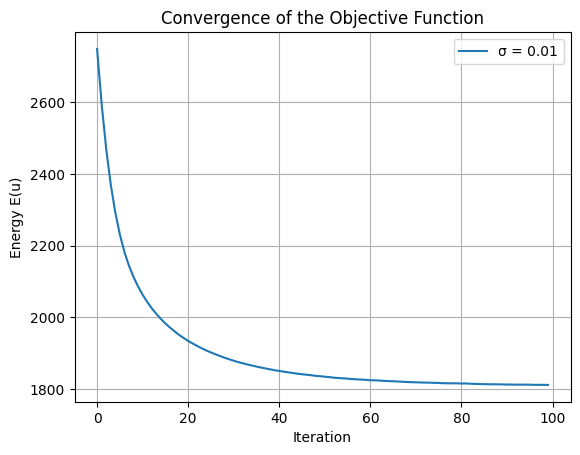

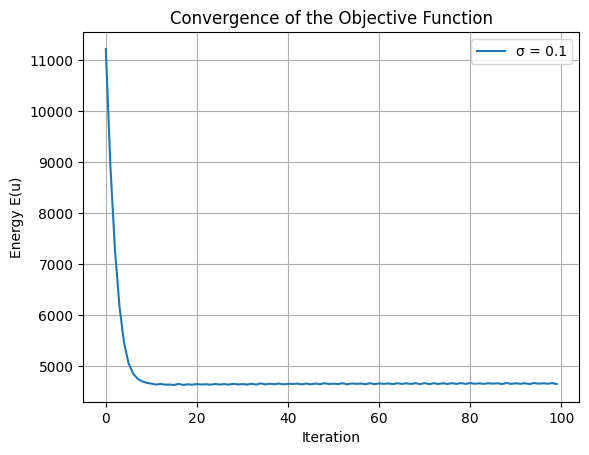

In [11]:
# Plot the convergence graph for each noise level
plt.figure(figsize=(10, 6))

for sigma in sigmas:
    E_list = energy_lists[sigma]
    plt.plot(E_list, label=f'σ = {sigma}')
    plt.xlabel('Iteration')
    plt.ylabel('Energy E(u)')
    plt.title('Convergence of the Objective Function')
    plt.legend()
    plt.grid(True)
    plt.show()



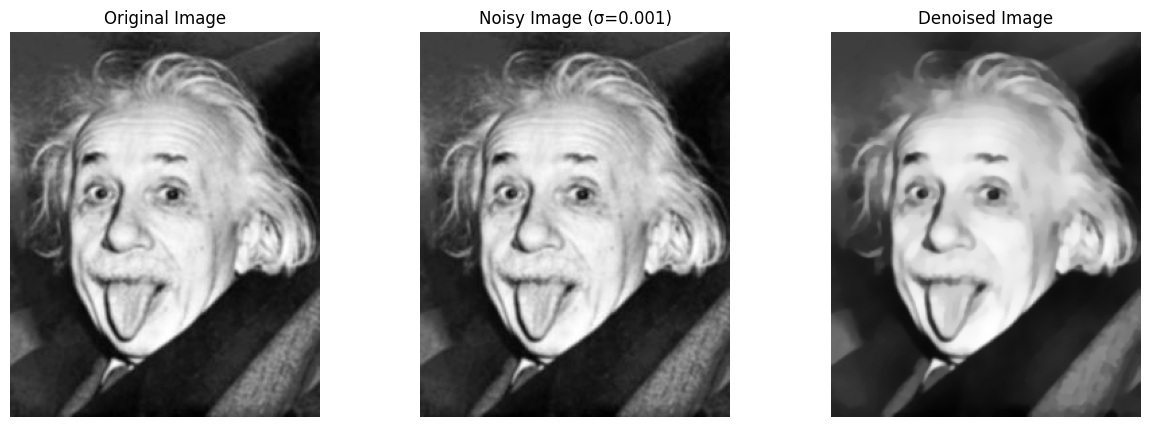

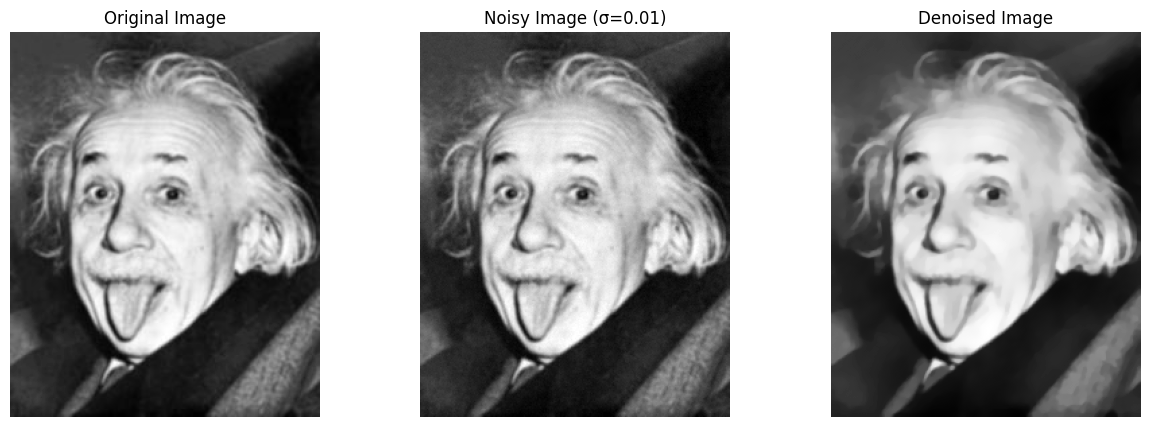

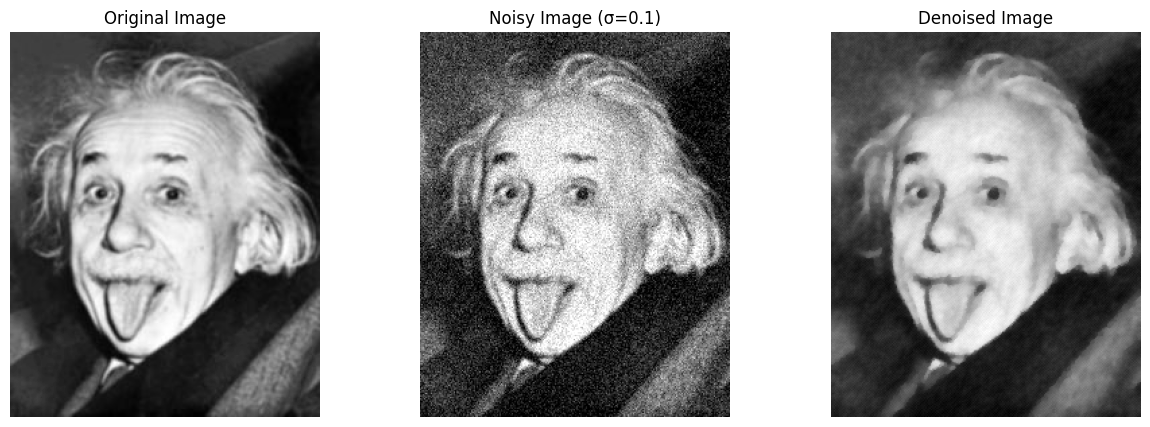

In [12]:
# Function to display images side by side
def display_images(images, titles, cmap='gray'):
    n = len(images)
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Compare images for each noise level
for sigma in sigmas:
    f_noisy = noisy_images[sigma]
    u_denoised = denoised_images[sigma]
    
    images = [image_np, f_noisy, u_denoised]
    titles = ['Original Image', f'Noisy Image (σ={sigma})', 'Denoised Image']
    
    display_images(images, titles)

### Discussion
We have implemented the TV denoising algorithm to denoise the images with Gaussian noise. The algorithm uses gradient descent to minimize the total variation energy of the image. We have applied the algorithm to images with different levels of noise (σ = 0.001, 0.01, 0.1). and parameters for each noise level were selected based on the convergence behavior of the algorithm. The denoised images show a significant reduction in noise while preserving the important features of the original image. The convergence graphs show that the energy function decreases with iterations, indicating that the algorithm is minimizing the total variation energy of the image. The denoised images show clear reduction in noise and the important feature in images are preserved. However, the denoised image with σ = 0.1 has artifacts due to high noise level. These artifacts and smoothening can also be seen in the denoised images with lower noise images in which the noise is barely visible.This could potentially be one of the limitations of the TV denoising algorithm where even though there is not much noise in the image, the algorithm might still introduce some artifacts. It has also been observed that the parameter selection for the algorithm plays a crucial role in the denoising process. The right selection of parameters can lead to better denoising results. But choosing the wrong parameters can lead to artifacts that can reduce the quality of the denoised image.